In [1]:
# Test for Yolo v8
#!pip install ultralytics

import pandas as pd
from ultralytics import YOLO

In [2]:
model  = YOLO("yolov8n.pt")  # load a pretrained model (recommended for training)
results = model(["/home/enric_sena/Desktop/prova_enric/data/processed/breast_region_crops_v2/D2-0424_96049_01543_1-3_ann3899.png"])

for result in results:
    boxes = result.boxes
    masks = result.masks
    keypoints = result.keypoints
    probs = result.probs
    obb = result.obb
    result.show()



0: 640x640 1 vase, 7.5ms
Speed: 43.9ms preprocess, 7.5ms inference, 13.8ms postprocess per image at shape (1, 3, 640, 640)


In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model(
    "/home/enric_sena/Desktop/prova_enric/data/processed/breast_region_crops_v2/D2-0424_96049_01543_1-3_ann3899.png"
)

for result in results:
    result.show()
    print(result.boxes)
    result.save(filename="prova_yolov8.png")


image 1/1 /home/enric_sena/Desktop/prova_enric/data/processed/breast_region_crops_v2/D2-0424_96049_01543_1-3_ann3899.png: 640x640 1 vase, 7.3ms
Speed: 2.9ms preprocess, 7.3ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)
Error: no "view" rule for type "image/png" passed its test case
       (for more information, add "--debug=1" on the command line)


ultralytics.engine.results.Boxes object with attributes:

cls: tensor([75.], device='cuda:0')
conf: tensor([0.5626], device='cuda:0')
data: tensor([[142.5638,   2.1468, 373.2065, 506.8303,   0.5626,  75.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (512, 512)
shape: torch.Size([1, 6])
xywh: tensor([[257.8852, 254.4885, 230.6427, 504.6835]], device='cuda:0')
xywhn: tensor([[0.5037, 0.4970, 0.4505, 0.9857]], device='cuda:0')
xyxy: tensor([[142.5638,   2.1468, 373.2065, 506.8303]], device='cuda:0')
xyxyn: tensor([[0.2784, 0.0042, 0.7289, 0.9899]], device='cuda:0')


In [4]:
# Adapt model to vindr data

DICOM_BASE = "/mnt/cafetera/mammo/vindr/images"
ANNOTATIONS = "/home/enric_sena/Desktop/prova_enric/vindr_dataset/finding_annotations.csv"

# Load annotations, preview them, and choose one annotated image for testing.
annotations = pd.read_csv(ANNOTATIONS)
df=annotations # per practicitat més endavant
df.head()

sample_images = df[df["xmin"].notna()][['study_id','image_id']].drop_duplicates().sample(1, random_state=42)


In [5]:
print(df.columns.tolist())
print(df.shape)

print("\nClasses:")
print(df["finding_categories"].value_counts())

print("\nExemple:")
print(df[[
    "study_id",
    "image_id",
    "finding_categories",
    "xmin",
    "ymin",
    "xmax",
    "ymax"
]].head(10))

['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax', 'split']
(20486, 16)

Classes:
finding_categories
['No Finding']                                                                                      18232
['Mass']                                                                                             1123
['Suspicious Calcification']                                                                          402
['Focal Asymmetry']                                                                                   232
['Architectural Distortion']                                                                           95
['Asymmetry']                                                                                          90
['Suspicious Calcification', 'Mass']                                                                   82
['Suspicious 

In [10]:
# Files amb més d'una categoria
multi = df[df["finding_categories"].apply(lambda x: len(x) > 1)]

print(multi[
    ["study_id", "image_id", "finding_categories",
     "xmin", "ymin", "xmax", "ymax"]
].head(20).to_string(index=False))

# Distribució del split original
print(df.groupby("split")["study_id"].nunique())

print("\nImatges:")
print(df.groupby("split")["image_id"].nunique())




# Quantes bboxes reals tenim per classe simple
single = df[df["finding_categories"].apply(lambda x: len(x) == 1)].copy()

single["class"] = single["finding_categories"].apply(lambda x: x[0])

print(
    single[single["class"] != "No Finding"]["class"]
    .value_counts()
)




# Només imatges que tenen una anotació
annotated = df[df["xmin"].notna()].copy()

# 15 imatges diferents
sample = (
    annotated[["study_id", "image_id"]]
    .drop_duplicates()
    .sample(15, random_state=42)
)

print(sample)

                        study_id                         image_id            finding_categories        xmin        ymin        xmax        ymax
48575a27b7c992427041a82fa750d3fa 4e3a578fe535ea4f5258d3f7f4419db8                      ['Mass'] 2355.139893 1731.640015 2482.979980 1852.750000
48575a27b7c992427041a82fa750d3fa dac39351b0f3a8c670b7f8dc88029364                      ['Mass'] 2386.679932 1240.609985 2501.800049 1354.040039
75e8e48933289d70b407379a564f8594 c83f780904f25eacb44e9030f32c66e1          ['Global Asymmetry'] 2279.179932 1166.510010 2704.439941 2184.260010
75e8e48933289d70b407379a564f8594 893528bc38a0362928a89364f1b692fd          ['Global Asymmetry'] 1954.270020 1443.640015 2589.760010 2193.810059
c3487424fee1bdd4515b72dc3fd69813 318264c881bf12f2c1efe5f93920cc37  ['Architectural Distortion'] 2172.300049 1967.410034 2388.699951 2147.159912
c3487424fee1bdd4515b72dc3fd69813 adf961b5379855af0293ca526f3d0c51  ['Architectural Distortion'] 2252.379883 2367.070068 2438.060059 2523

In [11]:
annotated = df[df["xmin"].notna()].copy()

sample = (
    annotated[["study_id", "image_id"]]
    .drop_duplicates()
    .sample(15, random_state=42)
)

print(sample)

                              study_id                          image_id
1128  9c8e8f688e99a35f6bb0a78cd4ae8d7e  9f65a2368a5df60f1910d687067ced3b
310   4a70ff4f20fa72a6943948ff05711ddd  89c3dd3095a646213c280c180094d87f
461   8abaf178e500859d0a532bf34a4ce595  be50a17b04aed1c7708217318ed8ba83
1114  77d2b897870fd48aacdc9b2bbad1ef52  870ec0cc5a1b1874d8c972a8595f41a2
594   cc764da4a23a0587b8e0249548af2393  472a2fe6865d2f3825e12758b3b194f2
1780  12c181a0785ed3b2c2b5f7cfc9f2667d  89537aa9ac593c57e7375f1572e3e773
1258  9bf5e07c124d149dc072232c005e033d  f97cd5b8d0049cbceda56350c01a66d5
380   8709bf15ee90717d41e647d921a6a357  72711c5c352ad731d4f832d693af1e8d
1220  9355c6b80ab80257f1c99ec644a5798e  bc58e54ec75acfc3acfb248f409ff2f4
1389  a0047350977a97f57d8dd43603907e87  f75e7aff7268ba2e462c284e30cfc5b5
1497  cbc4bb64487723a4b3af41c531deec7c  f51e0c5db5201a2cf58b424437007197
717   beb4eb26bfa74853d4b49172855eefe9  2a67cf5f900de22b0c45fb2c1d55dba4
1373  3f63d52243caf37caca6827d5d446b55  da211004c86

In [12]:
import os
import glob

for image_id in sample["image_id"]:
    matches = glob.glob(
        f"{DICOM_BASE}/**/{image_id}.dicom",
        recursive=True
    )
    print(image_id, matches)





9f65a2368a5df60f1910d687067ced3b ['/mnt/cafetera/mammo/vindr/images/9c8e8f688e99a35f6bb0a78cd4ae8d7e/9f65a2368a5df60f1910d687067ced3b.dicom']
89c3dd3095a646213c280c180094d87f ['/mnt/cafetera/mammo/vindr/images/4a70ff4f20fa72a6943948ff05711ddd/89c3dd3095a646213c280c180094d87f.dicom']
be50a17b04aed1c7708217318ed8ba83 ['/mnt/cafetera/mammo/vindr/images/8abaf178e500859d0a532bf34a4ce595/be50a17b04aed1c7708217318ed8ba83.dicom']
870ec0cc5a1b1874d8c972a8595f41a2 ['/mnt/cafetera/mammo/vindr/images/77d2b897870fd48aacdc9b2bbad1ef52/870ec0cc5a1b1874d8c972a8595f41a2.dicom']
472a2fe6865d2f3825e12758b3b194f2 ['/mnt/cafetera/mammo/vindr/images/cc764da4a23a0587b8e0249548af2393/472a2fe6865d2f3825e12758b3b194f2.dicom']
89537aa9ac593c57e7375f1572e3e773 ['/mnt/cafetera/mammo/vindr/images/12c181a0785ed3b2c2b5f7cfc9f2667d/89537aa9ac593c57e7375f1572e3e773.dicom']
f97cd5b8d0049cbceda56350c01a66d5 ['/mnt/cafetera/mammo/vindr/images/9bf5e07c124d149dc072232c005e033d/f97cd5b8d0049cbceda56350c01a66d5.dicom']
72711c

(3518, 2800)


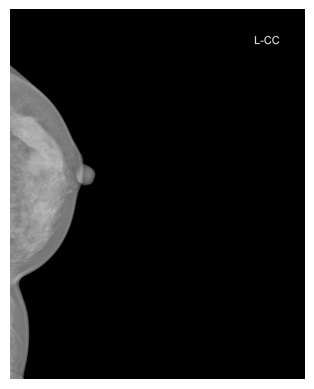

In [13]:
import pydicom
import matplotlib.pyplot as plt

image_id = sample.iloc[0]["image_id"]
path = matches[0]  # el match que acabes de trobar

ds = pydicom.dcmread(path)
img = ds.pixel_array

print(img.shape)

plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

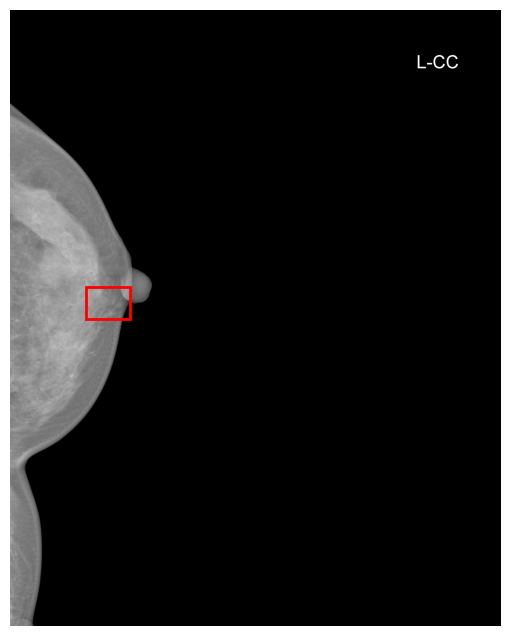

['Suspicious Calcification', 'Mass']
xmin     432.834015
ymin    1582.469971
xmax     683.301025
ymax     1762.02002
Name: 1128, dtype: object


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

row = df[df["image_id"] == image_id].iloc[0]

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img, cmap="gray")

rect = patches.Rectangle(
    (row["xmin"], row["ymin"]),
    row["xmax"] - row["xmin"],
    row["ymax"] - row["ymin"],
    linewidth=2,
    edgecolor="red",
    facecolor="none"
)

ax.add_patch(rect)
ax.axis("off")
plt.show()

print(row["finding_categories"])
print(row[["xmin", "ymin", "xmax", "ymax"]])

In [17]:
# Create dataset for YOLOv8 training with sample images and their bounding boxes
import os
import ast
import cv2
import pydicom
import yaml

OUT = "/home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo_test"

os.makedirs(f"{OUT}/images/train", exist_ok=True)
os.makedirs(f"{OUT}/labels/train", exist_ok=True)

for _, s in sample.iterrows():

    image_id = s["image_id"]

    # Busca el DICOM (aquí ja pots reutilitzar el match que has trobat)
    matches = glob.glob(
        f"{DICOM_BASE}/**/{image_id}*",
        recursive=True
    )
    path = matches[0]

    # Llegir DICOM
    ds = pydicom.dcmread(path)
    img = ds.pixel_array

    # Normalitzar a PNG
    img = cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX)
    img = img.astype("uint8")

    # Guardar imatge
    cv2.imwrite(
        f"{OUT}/images/train/{image_id}.png",
        img
    )

    # Totes les anotacions d'aquesta imatge
    rows = df[df["image_id"] == image_id]

    h, w = img.shape[:2]

    with open(
        f"{OUT}/labels/train/{image_id}.txt",
        "w"
    ) as f:

        for _, row in rows.iterrows():

            if pd.isna(row["xmin"]):
                continue

            # bbox → YOLO normalitzat
            xc = ((row["xmin"] + row["xmax"]) / 2) / w
            yc = ((row["ymin"] + row["ymax"]) / 2) / h
            bw = (row["xmax"] - row["xmin"]) / w
            bh = (row["ymax"] - row["ymin"]) / h

            f.write(
                f"0 {xc} {yc} {bw} {bh}\n"
            )

# YAML
data = {
    "path": OUT,
    "train": "images/train",
    "val": "images/train",
    "nc": 1,
    "names": ["lesion"]
}

with open(f"{OUT}/data.yaml", "w") as f:
    yaml.dump(data, f)

print("Dataset creat:", OUT)

Dataset creat: /home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo_test


In [18]:
from pathlib import Path

images = list(Path(f"{OUT}/images/train").glob("*.png"))
labels = list(Path(f"{OUT}/labels/train").glob("*.txt"))

print("Imatges:", len(images))
print("Labels:", len(labels))

print("\nExemple label:")
print(labels[0].read_text())

Imatges: 15
Labels: 15

Exemple label:
0 0.8955071585519107 0.4922143395073053 0.11295715332032143 0.10748721280511654



In [19]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=f"{OUT}/data.yaml",
    epochs=30,
    imgsz=1024,
    batch=4,
    device=0
)

Ultralytics 8.4.144 🚀 Python-3.10.6 torch-2.14.0+cu130 CUDA:0 (NVIDIA GeForce RTX 2080 Ti, 10812MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo_test/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

In [22]:

model = YOLO("/home/enric_sena/Desktop/Mammo/runs/detect/train/weights/best.pt")

results = model(
    "/home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo_test/images/train/2a67cf5f900de22b0c45fb2c1d55dba4.png",
    conf=0.25
)

results[0].save("test_prediction.png")


image 1/1 /home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo_test/images/train/2a67cf5f900de22b0c45fb2c1d55dba4.png: 1024x832 (no detections), 7.5ms
Speed: 5.1ms preprocess, 7.5ms inference, 0.6ms postprocess per image at shape (1, 3, 1024, 832)


'test_prediction.png'